# House Price Prediction

Name: Peddi Arjun

Internship Week 1 Project

# Task 1: Data Loading and Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("Housing.csv")
df.head(10)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
5,Super built-up Area,Ready To Move,Whitefield,2 BHK,DuenaTa,1170,2.0,1.0,38.00
6,Super built-up Area,18-May,Old Airport Road,4 BHK,Jaades,2732,4.0,NaN,204.00
7,Super built-up Area,Ready To Move,Rajaji Nagar,4 BHK,Brway G,3300,4.0,NaN,600.00
8,Super built-up Area,Ready To Move,Marathahalli,3 BHK,NaN,1310,3.0,1.0,63.25
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,NaN,1020,6.0,NaN,370.00


In [5]:
df.shape

(13320, 9)

In [6]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

# Task 2: Data Cleaning

In [7]:
df = df.drop_duplicates()

df["bath"] = df["bath"].fillna(df["bath"].median())

df["balcony"] = df["balcony"].fillna(df["balcony"].median())

df["location"] = df["location"].fillna("Unknown")

df["society"] = df["society"].fillna("Unknown")

In [8]:
def convert_sqft(x):
    try:
        return float(x)
    except:
        return np.nan

df["total_sqft"] = df["total_sqft"].apply(convert_sqft)

df = df.dropna(subset=["total_sqft"])

In [10]:
df["bhk"] = df["size"].str.extract(r"(\d+)")

df["bhk"] = pd.to_numeric(df["bhk"], errors="coerce")

In [11]:
df.drop(
    ["size", "society", "availability"],
    axis=1,
    inplace=True
)

In [12]:
df = pd.get_dummies(
    df,
    columns=["area_type", "location"],
    drop_first=True
)

In [13]:
df.head()

,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_ Banaswadi,location_ Basavangudi,...,location_rr nagar,location_sankeswari,location_sapthagiri Layout,location_sarjapura main road,location_singapura paradise,location_t.c palya,location_tc.palya,location_vinayakanagar,"location_white field,kadugodi",location_whitefiled
0,1056.0,2.0,1.0,39.07,2.0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,120.00,4.0,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,62.00,3.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,95.00,3.0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,51.00,2.0,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


# Task 3 - Model Building

In [14]:
X = df.drop("price", axis=1)

y = df["price"]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

In [21]:
print(df.isnull().sum())

total_sqft                       0
bath                             0
balcony                          0
price                            0
bhk                              8
                                ..
location_t.c palya               0
location_tc.palya                0
location_vinayakanagar           0
location_white field,kadugodi    0
location_whitefiled              0
Length: 1306, dtype: int64


In [22]:
# Fill all remaining numeric missing values

for col in df.columns:
    if df[col].dtype != "object":
        df[col] = df[col].fillna(df[col].median())

# Check again

print(df.isnull().sum().sum())

0


In [23]:
X = df.drop("price", axis=1)

y = df["price"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [28]:
mae_lr = mean_absolute_error(y_test, lr_pred)

rmse_lr = np.sqrt(mean_squared_error(y_test, lr_pred))

r2_lr = r2_score(y_test, lr_pred)

print("Linear Regression Results")

print("MAE =", mae_lr)

print("RMSE =", rmse_lr)

print("R2 Score =", r2_lr)

Linear Regression Results
MAE = 45.40373703361377
RMSE = 120.43610259061684
R2 Score = 0.4510438637115137


In [31]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [34]:
mae_rf = mean_absolute_error(y_test, rf_pred)

rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))

r2_rf = r2_score(y_test, rf_pred)

print("Random Forest Results")

print("MAE =", mae_rf)

print("RMSE =", rmse_rf)

print("R2 Score =", r2_rf)

Random Forest Results
MAE = 35.038098672550305
RMSE = 117.47336389112266
R2 Score = 0.4777203933599228


In [35]:
comparison = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_lr, mae_rf],
    "RMSE":[rmse_lr, rmse_rf],
    "R2 Score":[r2_lr, r2_rf]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,45.403737,120.436103,0.451044
1,Random Forest,35.038099,117.473364,0.477720


# Task 4 - Visualization

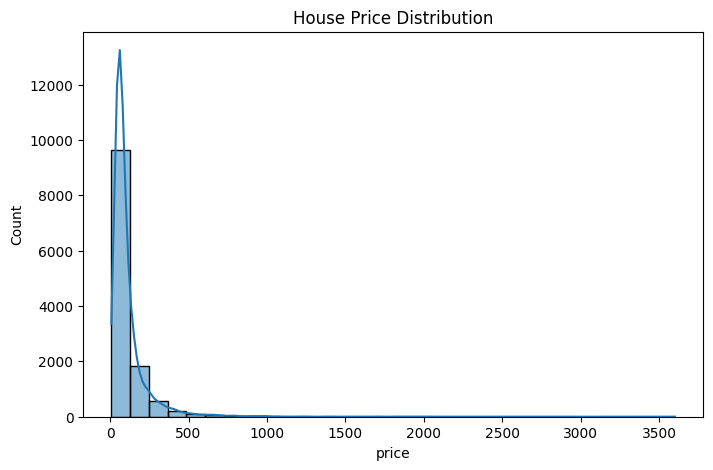

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("House Price Distribution")

plt.show()

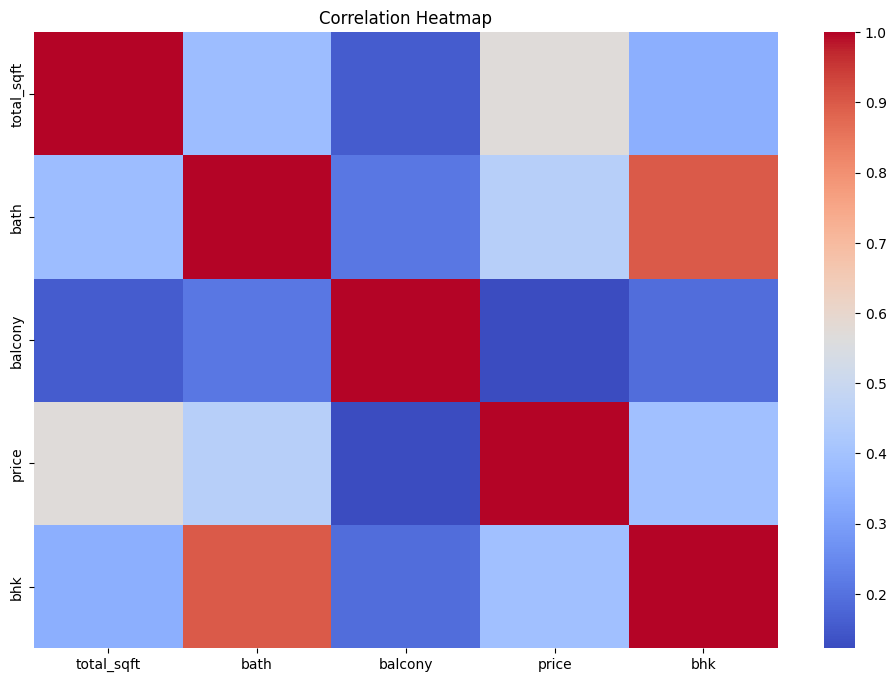

In [37]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

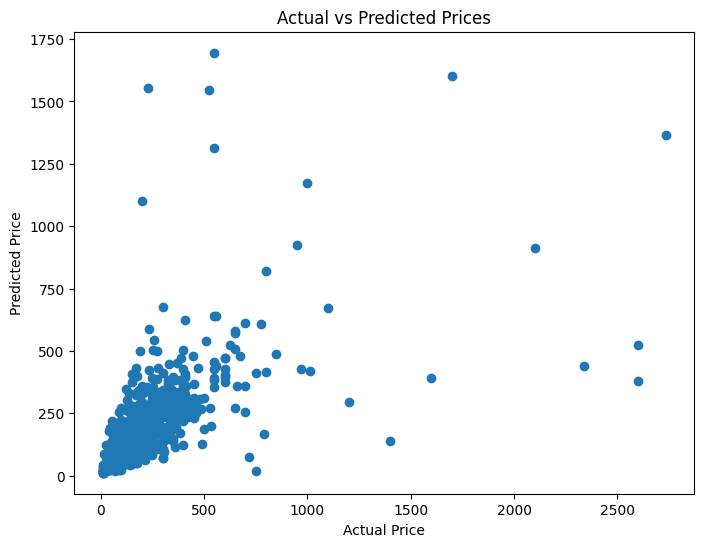

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
0,total_sqft,0.582160
1,bath,0.080900
3,bhk,0.027934
365,location_Defence Colony,0.019156
2,balcony,0.016139
5,area_type_Plot Area,0.015943
976,location_Rajaji Nagar,0.014325
1266,location_Yemlur,0.014126
276,location_Bommenahalli,0.014085
788,location_Malleshwaram,0.013642


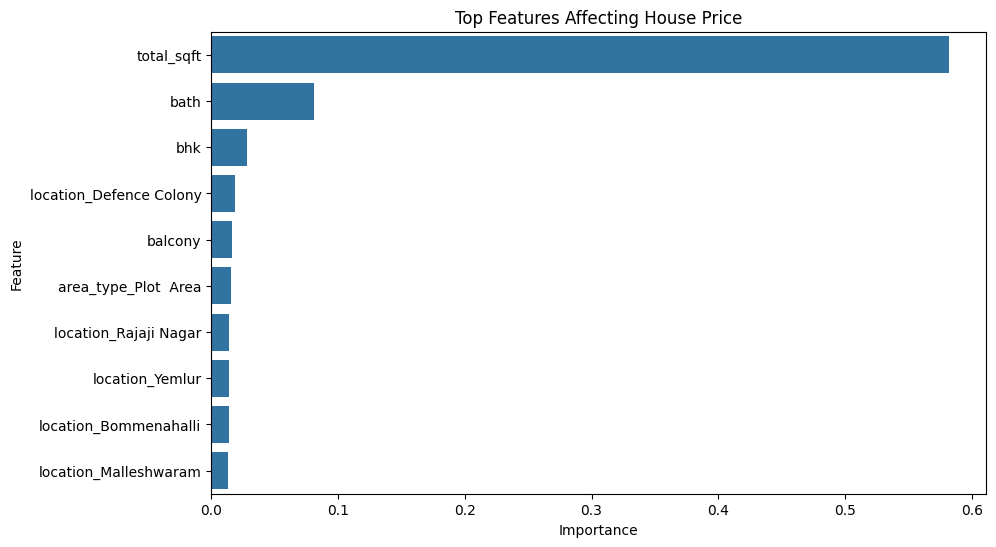

In [40]:
top_features = importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Affecting House Price")

plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Task 5 - Insights and Summary

## Insights

1. Random Forest performed better than Linear Regression in predicting house prices.

2. Features such as total_sqft, bhk, bath, and location had a strong influence on house prices.

3. Larger houses generally had higher prices.

4. Location played an important role in determining the value of a property.

5. The model achieved good prediction accuracy and can help buyers and sellers estimate property prices.

6. Real estate companies should focus on larger properties in premium locations because they generate higher market value.